In [2]:
import sys
if "vision_env" not in sys.executable:
    print("/n环境配置错误!!!/n")
    print(sys.executable)
else:
    print("环境配置正常")

环境配置正常


In [3]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib import rcParams # 字体配置,支持中文
rcParams['font.family'] = 'SimHei'
rcParams['axes.unicode_minus'] = False  # 解决负号不显示的问题

import cv2

print("opencv:", cv2.__version__)
print("numpy:", np.__version__)

opencv: 4.13.0
numpy: 2.2.5


<font color = #000000 >

## 2-1 图像读取与保存
+ 重点在于以下流程
    + 读取图像
    + 判断是否为None
    + 不是None的话就进行操作
    + waitkey + destroy操作退出
</font>


In [4]:
picture = '../Pictures/'
# 定义图像展示函数
def img_show(img):
    if img is None:
        print("图像读取失败")
    else:
        # 图像展示
        cv2.imshow("image", img)    # 首先需要确定图像存在才能打开
        print(img.shape)
        cv2.waitKey(0)  # 等待时间,0对应无限等待,知道按下任意按键
        cv2.destroyAllWindows() 

In [5]:
# 图像读取:BGR
img = cv2.imread(picture + 'cat.jpg') # 默认BGR格式读取: 3维, 每一个点为3通道值

img_show(img=img)

cv2.waitKey(0)  # 等待时间,0对应无限等待,知道按下任意按键

cv2.destroyAllWindows() 

(414, 500, 3)


In [6]:
# 图像读取:灰度
img = cv2.imread('../Pictures/cat.jpg' , cv2.IMREAD_GRAYSCALE) 

img_show(img=img)

cv2.waitKey(0)  # 等待时间,0对应无限等待,知道按下任意按键

cv2.destroyAllWindows() 


(414, 500)


In [7]:
# 图像保存
cv2.imwrite('mycat.png',img)    # type: ignore , 其实需要判断img是否存在

True

<font color = #000000>

## 2-2 视频读取
</font>

In [8]:
vc = cv2.VideoCapture('../pictures/test.mp4')

if (vc.isOpened()):
    open, frame = vc.read() # 图像是否打开 , 图像:frame
else:
    print("视频打开失败")
    open = False

while(open):
    ret , frame = vc.read() # ret只能判断是否打开,不能判断是否关闭  视频为空: frame = false
    if (frame is None):
        break
    if (ret == True):
        gray = cv2.cvtColor(frame , cv2.COLOR_BGR2GRAY)
        cv2.imshow("result" , gray)
        if (cv2.waitKey(1) & 0xFF == 27):   # ESC退出
            break

vc.release() 
cv2.destroyAllWindows()

<font color = #000000>

## 2-3 截取部分图像数据
</font>

In [9]:
img = cv2.imread('../pictures/cat.jpg')

if img is None:
    print("图片读取失败")
else:
    cat = img[0:120, 0:200] # 截取部分区域,其实是三通道,但是第3个是颜色相关的,所以前两个通道可以裁切尺寸

    print(f"Img_Shape:{img.shape} , Cat_Shape:{cat.shape}")

    cv2.imshow('mycat.png', cat)
    cv2.waitKey(0)
    cv2.destroyAllWindows()


Img_Shape:(414, 500, 3) , Cat_Shape:(120, 200, 3)


In [10]:
# 2-3-1 颜色通道提取
b,g,r = cv2.split(img)  # type: ignore

# 重组
img = cv2.merge((b,g,r))
img.shape

(414, 500, 3)

In [13]:
# 2-3-2 只保留一个
cur_img = img.copy() # 切记是BGR
cur_img[:,:,2] = 0 # B为0
cur_img[:,:,1] = 0 # G为0
img_show(cur_img)

(414, 500, 3)


<font color = #000000>

## 2-4 边界填充
</font>

| 类型          | 原理    | 效果   |
| ----------- | ----- | ---- |
| REPLICATE   | 复制边缘  | 最简单  |
| REFLECT     | 镜像    | 平滑   |
| REFLECT_101 | 去边界镜像 | 最常用  |
| WRAP        | 循环    | 周期信号 |
| CONSTANT    | 固定值   | 黑边   |

- BORDER_REPLICATE：复制法，也就是复制最边缘像素。
- BORDER_REFLECT：反射法，对感兴趣的图像中的像素在两边进行复制例如：fedcba|abcdefgh|hgfedcb   
- BORDER_REFLECT_101：反射法，也就是以最边缘像素为轴，对称，gfedcb|abcdefgh|gfedcba
- BORDER_WRAP：外包装法cdefgh|abcdefgh|abcdefg  
- BORDER_CONSTANT：常量法，常数值填充。

In [ ]:
top_size, bottom_size , left_size , right_size = (50,50,50,50)
# 边界填充
# REPLICATE（复制边缘像素）
replicate = cv2.copyMakeBorder(img, top_size, bottom_size, left_size, right_size, borderType=cv2.BORDER_REPLICATE)
# REFLECT（镜像翻转）
reflect = cv2.copyMakeBorder(img, top_size, bottom_size, left_size, right_size,cv2.BORDER_REFLECT)
# REFLECT_101（去掉边界像素的镜像）
reflect101 = cv2.copyMakeBorder(img, top_size, bottom_size, left_size, right_size, cv2.BORDER_REFLECT_101)
# WRAP（循环平铺）
wrap = cv2.copyMakeBorder(img, top_size, bottom_size, left_size, right_size, cv2.BORDER_WRAP)
# CONSTANT（常数填充）
constant = cv2.copyMakeBorder(img, top_size, bottom_size, left_size, right_size,cv2.BORDER_CONSTANT, value=0)


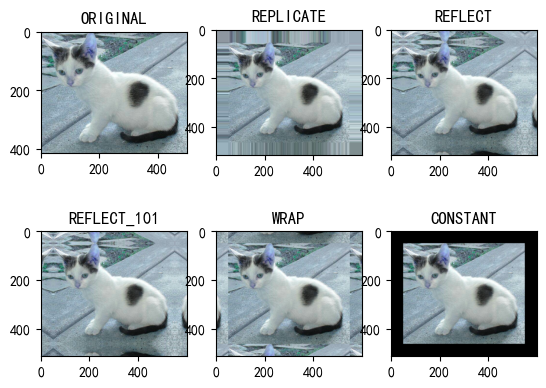

In [20]:
# 绘制图像
plt.subplot(231), plt.imshow(img, 'gray'), plt.title('ORIGINAL')
plt.subplot(232), plt.imshow(replicate, 'gray'), plt.title('REPLICATE')
plt.subplot(233), plt.imshow(reflect, 'gray'), plt.title('REFLECT')
plt.subplot(234), plt.imshow(reflect101, 'gray'), plt.title('REFLECT_101')
plt.subplot(235), plt.imshow(wrap, 'gray'), plt.title('WRAP')
plt.subplot(236), plt.imshow(constant, 'gray'), plt.title('CONSTANT')

plt.show()


<font color = #000000>

## 2-5 数值计算
</font>

In [39]:
img_cat=cv2.imread(picture + 'cat.jpg')
img_dog=cv2.imread(picture + 'dog.jpg')

In [23]:
img_cat2= img_cat +10 
print(img_cat[:5,:,0])
print(img_cat2[:5,:,0])

[[142 146 151 ... 156 155 154]
 [108 112 118 ... 155 154 153]
 [108 110 118 ... 156 155 154]
 [139 141 148 ... 156 155 154]
 [153 156 163 ... 160 159 158]]
[[152 156 161 ... 166 165 164]
 [118 122 128 ... 165 164 163]
 [118 120 128 ... 166 165 164]
 [149 151 158 ... 166 165 164]
 [163 166 173 ... 170 169 168]]


In [24]:
#相当于% 256
(img_cat + img_cat2)[:5,:,0] 

array([[ 38,  46,  56, ...,  66,  64,  62],
       [226, 234, 246, ...,  64,  62,  60],
       [226, 230, 246, ...,  66,  64,  62],
       [ 32,  36,  50, ...,  66,  64,  62],
       [ 60,  66,  80, ...,  74,  72,  70]], shape=(5, 500), dtype=uint8)

In [25]:
# 直接超过就满
cv2.add(img_cat,img_cat2)[:5,:,0]

array([[255, 255, 255, ..., 255, 255, 255],
       [226, 234, 246, ..., 255, 255, 255],
       [226, 230, 246, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], shape=(5, 500), dtype=uint8)

<font color = #000000>

## 2-6 图像融合与裁切
</font>

In [40]:
# 图像融合需要像素shape一样
try : 
    a = img_cat + img_dog
except Exception as e:
    print("出错了", e )
    print('img_dog.shape = ' , img_dog.shape)
    print('img_cat.shape = ' , img_cat.shape)

出错了 operands could not be broadcast together with shapes (414,500,3) (429,499,3) 
img_dog.shape =  (429, 499, 3)
img_cat.shape =  (414, 500, 3)


In [41]:
# 修改像素尺寸
img_show(img_dog)
# 记得这里OpenCV 中 resize() 的参数顺序 和 shape 的顺序不同!
# 原因: cv视觉是x,y轴,x是向右,y是向下,所以x对应就是width(n) , y -> m (m*n)
img_dog = cv2.resize(img_dog, (500, 414))  
img_show(img_dog)

(429, 499, 3)
(414, 500, 3)


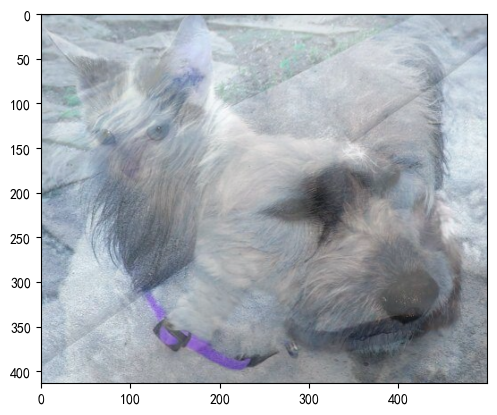

In [43]:
# 融合
res = cv2.addWeighted(img_cat, 0.4, img_dog, 0.6, 0)
plt.imshow(res)

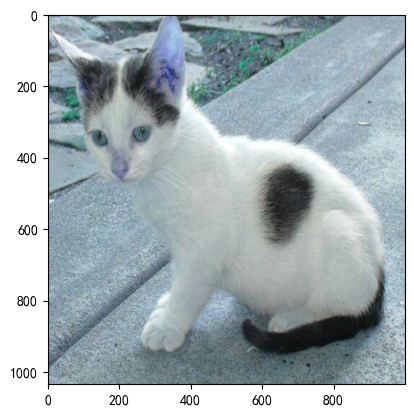

In [51]:
# 像素size改变:
'''
新宽度  = 原宽度 x fx
新高度  = 原高度 x fy
'''
res = cv2.resize(img, (0, 0), fx=2, fy=2.5)
plt.imshow(res)

<font color = #000000>

## 参考格式
</font>